In [317]:
import torch
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import pathlib
import seaborn as sns

from torchvision import transforms, datasets
# from torchmetrics.classification import MulticlassAccuracy
from torchmetrics.regression import R2Score
# from torchvision import dataset
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import random

/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [195]:
path = pathlib.Path.home() / "Downloads/csiro-biomass"

train = pd.read_csv(path / "train.csv")
test = pd.read_csv(path / "test.csv")

In [196]:
train.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


In [197]:
test.head()

,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


In [198]:
train['target_name']

0       Dry_Clover_g
1         Dry_Dead_g
2        Dry_Green_g
3        Dry_Total_g
4              GDM_g
            ...     
1780    Dry_Clover_g
1781      Dry_Dead_g
1782     Dry_Green_g
1783     Dry_Total_g
1784           GDM_g
Name: target_name, Length: 1785, dtype: object

In [199]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_id      1785 non-null   object 
 1   image_path     1785 non-null   object 
 2   Sampling_Date  1785 non-null   object 
 3   State          1785 non-null   object 
 4   Species        1785 non-null   object 
 5   Pre_GSHH_NDVI  1785 non-null   float64
 6   Height_Ave_cm  1785 non-null   float64
 7   target_name    1785 non-null   object 
 8   target         1785 non-null   float64
dtypes: float64(3), object(6)
memory usage: 125.6+ KB


In [200]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sample_id    5 non-null      object
 1   image_path   5 non-null      object
 2   target_name  5 non-null      object
dtypes: object(3)
memory usage: 252.0+ bytes


In [201]:
train.describe()

,Pre_GSHH_NDVI,Height_Ave_cm,target
count,1785.000000,1785.000000,1785.000000
mean,0.657423,7.595985,24.782295
std,0.151972,10.273725,25.823738
min,0.160000,1.000000,0.000000
25%,0.560000,3.000000,4.818200
50%,0.690000,4.000000,18.200000
75%,0.770000,7.000000,35.940600
max,0.910000,70.000000,185.700000


In [202]:
# train_loader = DataLoader()

label = {label: idx for idx, label in enumerate(train["target_name"].unique())}
label

{'Dry_Clover_g': 0,
 'Dry_Dead_g': 1,
 'Dry_Green_g': 2,
 'Dry_Total_g': 3,
 'GDM_g': 4}

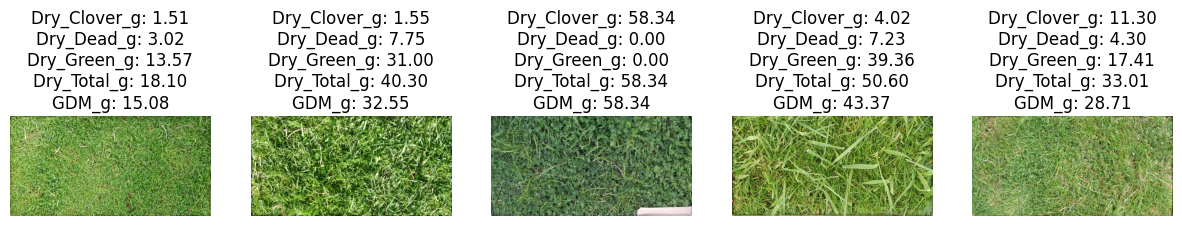

In [203]:
sample = train["image_path"].unique()
rand_image = random.sample(list(sample), 5)

# values = []

fig, axis = plt.subplots(1, len(rand_image), figsize = (15, 8))

for ax, img_path in zip(axis, rand_image):
    image = Image.open(path / img_path).convert("RGB")
    targets = train[train["image_path"] == img_path][["target_name", "target"]]
    
    # plt.figure(figsize = (5, 5))
    ax.imshow(image)
    ax.set_title("\n".join(f"{r.target_name}: {r.target:.2f}" for r in targets.itertuples()))
    # ax.set_title(targets)
    ax.axis("off")
    # ax.show()

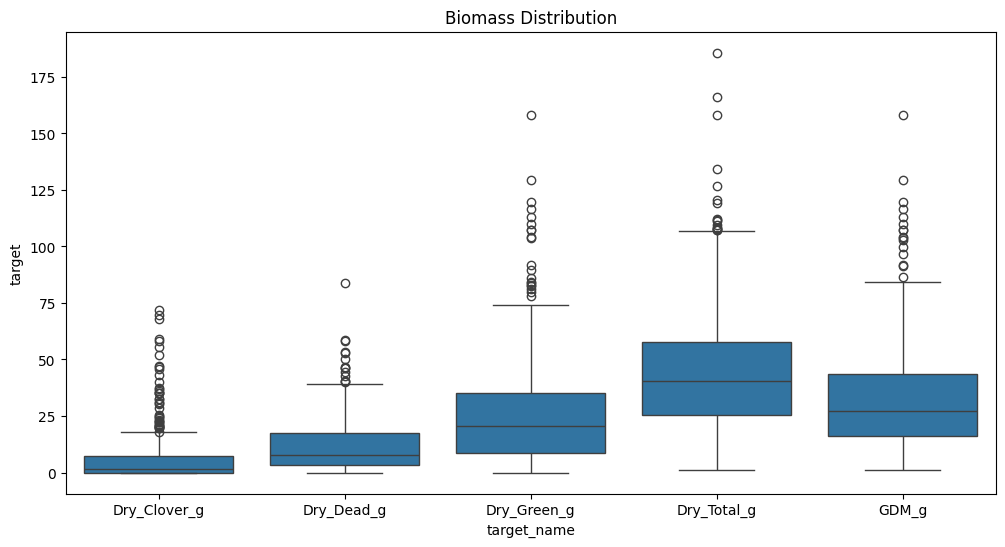

In [204]:
plt.figure(figsize=(12, 6))
sns.boxplot(train, x = "target_name", y = "target")
plt.title("Biomass Distribution")
plt.show()

In [205]:
pivot = train.pivot(index = "image_path", columns = "target_name", values = "target")
corr = pivot.corr()
corr

target_name,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
target_name,,,,,
Dry_Clover_g,1.000000,-0.175548,-0.276582,0.104185,0.204213
Dry_Dead_g,-0.175548,1.000000,0.095554,0.453912,0.012028
Dry_Green_g,-0.276582,0.095554,1.000000,0.830315,0.884257
Dry_Total_g,0.104185,0.453912,0.830315,1.000000,0.896441
GDM_g,0.204213,0.012028,0.884257,0.896441,1.000000


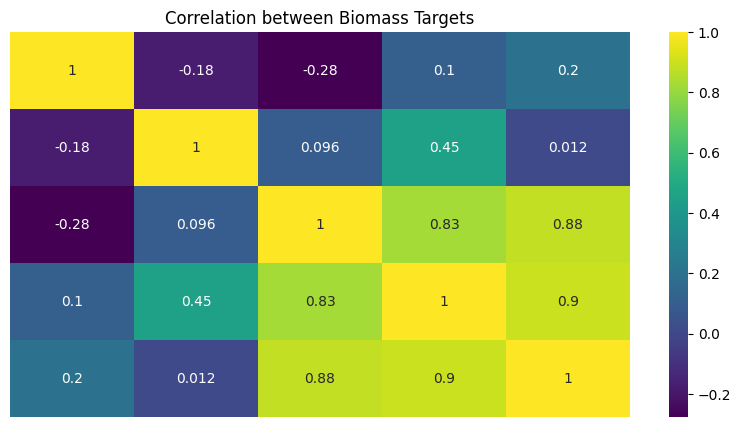

In [206]:
plt.figure(figsize = (10, 5))
sns.heatmap(corr, annot = True, cmap = "viridis")
plt.title("Correlation between Biomass Targets")
plt.axis("off")
plt.show()

<Axes: >

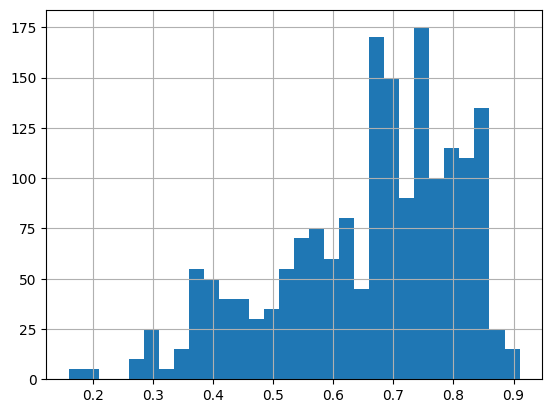

In [207]:
train["Pre_GSHH_NDVI"].hist(bins=30)

<Axes: >

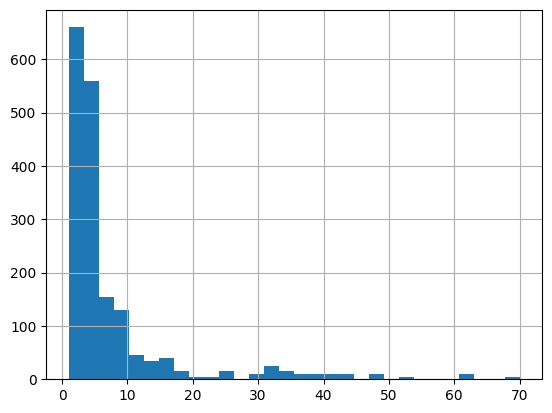

In [208]:
train["Height_Ave_cm"].hist(bins=30)

In [209]:
# label[train["target_name"]]

# lst = []

# for idx, target in enumerate(train["target_name"]):
#     ...

In [210]:
# path = pathlib.Path.home() / "Downloads/csiro-biomass" / "train/ID1463690813.jpg"

# image = Image.open(path).convert("RGB")
# path.name
# image

In [211]:
# import torch
# from torch.utils.data import Dataset, DataLoader
# import pandas as pd
# from PIL import Image
# from torchvision import transforms
# from pathlib import Path

# class BiomassDataset(Dataset):
#     def __init__(self, csv_file, transform=None):
#         super().__init__()

#         self.annotation = pd.read_csv(csv_file)
#         self.transform = transform
#         self.base_path = Path.home() / "Downloads/csiro-biomass"

#         self.label_to_idx = {label: idx for idx, label in enumerate(self.annotation["target_name"].unique())}

#     def __len__(self):
#         return len(self.annotation)

#     def __getitem__(self, idx):
#         row = self.annotation.iloc[idx]
#         image_path = self.base_path / row["image_path"]
#         label_name = row["target_name"]
#         label = self.label_to_idx[label_name]

#         image = Image.open(image_path).convert("RGB")

#         if self.transform:
#             image = self.transform(image)

#         return image, torch.tensor(label, dtype=torch.long)

In [212]:
# transform = transforms.Compose(
#     [
#         transforms.Resize((224, 224)),
#         transforms.ToTensor()
#     ]
# )

# dataset = BiomassDataset(csv_file = path / "train.csv", transform = transform)
# data_loader = DataLoader(dataset, batch_size = 32, shuffle = True)
# image, label = next(iter(data_loader))

# image.shape

In [213]:
# dataset.classes

In [214]:
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

# _traindata = datasets.ImageFolder(root = path / "train", transform = transforms)
# train_loader = DataLoader(
#     _traindata,
#     shuffle = True,
#     batchsize = 10
# )

# _testdata = datasets.ImageFolder(root = path / "test", transform = transforms)
# test_loader = DataLoader(
#     _testdata,
#     shuffle = False,
#     batch_size = 10
# )

<Axes: xlabel='image_path'>

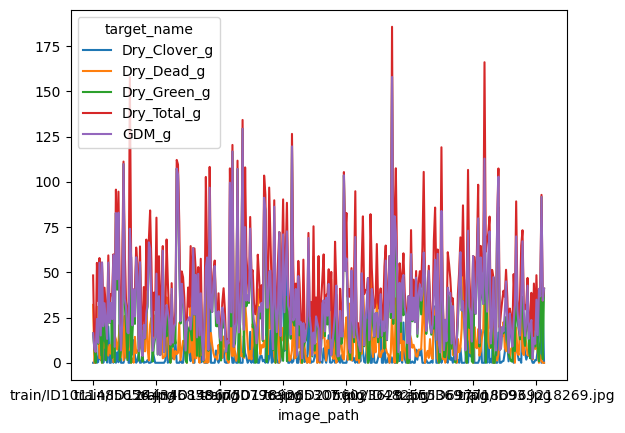

In [215]:
train.pivot_table(index = "image_path", columns = "target_name", values = "target").plot()

In [217]:
# test.pivot_table(index = "image_path", )

In [218]:
class BiomassDataset(Dataset):
    def __init__(self, csv_path, root, transform: None):
        super(BiomassDataset, self).__init__()

        self.annonation = pd.read_csv(csv_path)
        self.root = pathlib.Path(root)
        self.transform = transform

        self.grouped = (
            self.annonation
            .pivot_table(index = "image_path", columns = "target_name", values = "target")
            .reset_index()
        )
        self.target_cols = ["Dry_Clover_g", "Dry_Dead_g", "Dry_Green_g", "Dry_Total_g", "GDM_g"]

    def __len__(self):
        return len(self.grouped)

    def __getitem__(self, idx):
        rows = self.grouped.iloc[idx]
        img_path = self.root / rows["image_path"]
        image = Image.open(img_path).convert("RGB")

        # target = torch.tensor(rows[self.target_cols].values, dtype = torch.float)
        # targets = torch.from_numpy(rows[self.target_cols].values).type(torch.float32)
        # target = rows[self.target_cols].values
        target = pd.to_numeric(rows[self.target_cols], errors="coerce").astype("float32")
        target = torch.tensor(target.values, dtype=torch.float32)

        # print(type(target))

        if self.transform:
            image = self.transform(image)

        return image, target

In [262]:
class BiomassTestDataset(Dataset):
    def __init__(self, csv_path, root, transform = None):
        super(BiomassTestDataset, self).__init__()

        self.annonation = pd.read_csv(csv_path)
        self.root = pathlib.Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.annonation)

    def __getitem__(self, idx):
        rows = self.annonation.iloc[idx]
        
        img_path = self.root / rows["image_path"]
        image = Image.open(img_path).convert("RGB")

        # target = pd.to_numeric(rows["target_name"], errors = "coerce").astype("float32")
        # target = torch.tensor(target).type(torch.float32)

        target_name = rows["target_name"]
        sample_id = rows["sample_id"]

        if self.transform:
            image = self.transform(image)

        return image, target_name, sample_id

In [263]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [265]:
train_dataset = BiomassDataset(
    csv_path = path / "train.csv",
    root = path,
    transform = transform
)

test_dataset = BiomassTestDataset(
    csv_path = path / "test.csv",
    root = path,
    transform = transform
)

test_dataset

In [280]:
train_loader = DataLoader(
    dataset,
    shuffle = True,
    batch_size = 32
)

# loader.dataset
# for image, target in ...
# for image, label in loader:
#     print(label)

image, target = next(iter(train_loader))
image.shape, target.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32, 5]))

In [281]:
target.unique()

tensor([0.0000e+00, 1.0000e-01, 1.8340e-01, 4.0000e-01, 5.0000e-01, 6.0000e-01,
        8.0240e-01, 1.0962e+00, 1.1385e+00, 1.2000e+00, 1.3191e+00, 1.3446e+00,
        1.5500e+00, 1.6200e+00, 2.5000e+00, 2.9720e+00, 3.0196e+00, 3.1815e+00,
        3.2000e+00, 3.3889e+00, 3.8000e+00, 4.1948e+00, 4.5597e+00, 4.9327e+00,
        5.2000e+00, 6.0000e+00, 6.2143e+00, 6.4000e+00, 6.6000e+00, 6.7000e+00,
        6.7778e+00, 6.7982e+00, 6.8080e+00, 6.9000e+00, 7.1000e+00, 7.5000e+00,
        7.6000e+00, 7.7500e+00, 7.8492e+00, 8.4248e+00, 8.6171e+00, 9.2000e+00,
        9.5000e+00, 9.5934e+00, 1.0500e+01, 1.0880e+01, 1.1888e+01, 1.2035e+01,
        1.2060e+01, 1.2639e+01, 1.2836e+01, 1.2838e+01, 1.3100e+01, 1.3200e+01,
        1.3661e+01, 1.3895e+01, 1.4800e+01, 1.5700e+01, 1.5953e+01, 1.6136e+01,
        1.6311e+01, 1.6311e+01, 1.6489e+01, 1.6741e+01, 1.7443e+01, 1.8000e+01,
        1.8215e+01, 1.9083e+01, 2.0333e+01, 2.0900e+01, 2.1263e+01, 2.2471e+01,
        2.2520e+01, 2.2700e+01, 2.2786e+

In [282]:
test_loader = DataLoader(test_dataset,
                        shuffle = False,
                        batch_size = 1)

len(test_loader)

5

In [285]:
image, target, sid = next(iter(test_loader))

image.shape

torch.Size([1, 3, 224, 224])

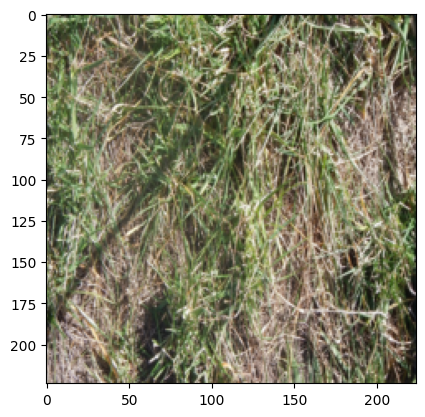

In [284]:
img = image.squeeze(0)
img = img.permute(1, 2, 0)
plt.imshow(img)

In [372]:
class BiomassModel(torch.nn.Module):
    def __init__(self, in_features: int = 3, 
                 out_features: int = 5, 
                 hidden_units: int = 64, 
                 batch_units: int = 32
                ):
        super(BiomassModel, self).__init__()

        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_units: int = batch_units

        self.convolutional_layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.in_features,
                              out_channels = self.hidden_units,
                              kernel_size = 3,
                              padding = 1,
                              stride = 1),
            torch.nn.BatchNorm2d(num_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = 2),
            torch.nn.Dropout2d(p = 0.25)
        )

        self.convolutional_layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.batch_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.BatchNorm2d(num_features = self.batch_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.batch_units,
                           out_channels = self.batch_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = 2),
            torch.nn.Dropout2d(p = 0.25)
        )

        self.regression = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.batch_units * 56 * 56,
                           out_features = self.batch_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Dropout(p = 0.25),
            torch.nn.Linear(in_features = self.batch_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.convolutional_layer1(x)
        # print(x.shape)
        x = self.convolutional_layer2(x)
        # print(x.shape)
        x = self.regression(x)
        return x

In [373]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [374]:
model = BiomassModel().to(device)
model

BiomassModel(
  (convolutional_layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (convolutional_layer2): Sequential(
    (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (regression): Sequential(
    (0): Flatten(start_dim=1, end

In [375]:
image.dim()

4

In [376]:
rand_image = torch.randn(size = (1, 3, 224, 224))

result = model(rand_image.to(device))
result

tensor([[ 0.0720, -0.0190, -0.0777,  0.0855, -0.0831]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [377]:
def train_model(model: torch.nn.Module,
               criterion: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device = "cpu",
               dataset = None,
               r2score = None
    ):
    model.train()

    running_loss = 0.0
    running_r2 = 0.0
    r2score.reset()

    for idx, (image, target) in enumerate(dataset):
        target_pred = model(image.to(device))
        loss = criterion(target_pred, target.to(device))
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        # accuracy
        running_loss += loss.item()
        # running_r2 += r2score(target, target_pred).compute().item()
        r2score.update(target_pred, target.to(device))

    avg_loss = running_loss / len(dataset)
    avg_r2score = r2score.compute().item()

    print(f"Traning Loss: {avg_loss:.4f} | R2Score: {avg_r2score:.4f}")
    # print(f)

    return {
        "model": model.__class__.__name__,
        "loss": avg_loss,
        "r2score": avg_r2score
    }

In [378]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
r2score = R2Score().to(device)

In [379]:
epochs = 15

total_epochs = []
losses = []
total_r2score = []

for epoch in tqdm(range(epochs)):
    trainModel = train_model(model = model,
                            criterion = criterion,
                            optimizer = optimizer,
                            device = device,
                            dataset = train_loader,
                            r2score = r2score)

    losses.append(trainModel.get("loss"))
    total_r2score.append(trainModel.get("r2score"))

    total_epochs.append(epoch)


  7%|██▉                                         | 1/15 [00:12<02:49, 12.10s/it]

Traning Loss: 644.8905 | R2Score: -0.3441



 13%|█████▊                                      | 2/15 [00:24<02:35, 12.00s/it]

Traning Loss: 521.3509 | R2Score: -0.1023



 20%|████████▊                                   | 3/15 [00:36<02:24, 12.01s/it]

...

Traning Loss: 233.0338 | R2Score: 0.4173



 93%|████████████████████████████████████████▏  | 14/15 [02:47<00:11, 11.96s/it]

Traning Loss: 215.8674 | R2Score: 0.4659



100%|███████████████████████████████████████████| 15/15 [02:59<00:00, 11.96s/it]

Traning Loss: 175.9112 | R2Score: 0.5711


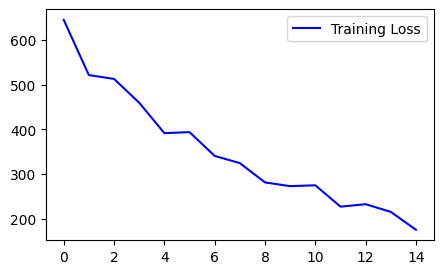

In [380]:
plt.figure(figsize=(5, 3))
plt.plot(total_epochs, losses, label = "Training Loss", c = "blue")
plt.legend()
plt.show()

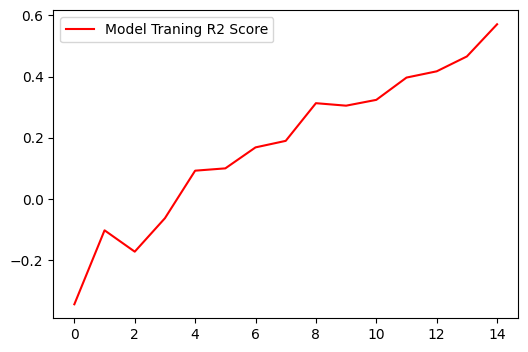

In [381]:
plt.figure(figsize=(6, 4))
plt.plot(total_epochs, total_r2score, label = "Model Traning R2 Score", c= "red")
plt.legend()
plt.show()